# Predictive Modeling of Hispanic Race Identification (National)

This notebook is the modeling stage of the project. It reads the merged
county-level dataset produced by `3hispanicclean.ipynb`
(`nation_census_and_geodata.parquet`) and asks which demographic covariates
predict each Hispanic race choice.

**Sections**

1. **Dominant-race classification** (`Most_SOR`, `Most_White_SOR`,
   `Most_White`): a naive baseline, an L1-regularized logistic regression, and
   a random forest, with feature-importance tables. Each section is followed by
   a written interpretation in markdown.
2. **Continuous race proportions**: random-forest regression with SHAP values,
   then several alternative regressors (polynomial Lasso, logit-transformed
   Lasso, and log-ratio Ridge/Lasso) that worked less well.

The markdown commentary cells contain the written analysis and are intended to
be read alongside each model's output.


In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
# Core data handling
import pandas as pd
import numpy as np

# Geospatial (kept for parity with the upstream notebooks)
import geopandas as gpd
import libpysal
from libpysal.weights import Queen
import gerrychain
from gerrychain import Graph
from esda.moran import Moran
from esda.smoothing import Empirical_Bayes

# Statistics
import scipy.stats as stats
import statsmodels.api as sm
import requests

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap

# scikit-learn modeling
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, log_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV, Ridge

In [2]:
# =============================================================================
# LOAD DATA & DEFINE COVARIATE LISTS
# =============================================================================
# Reads the merged dataset exported by 3hispanicclean.ipynb.
census_and_geodata = pd.read_parquet('nation_census_and_geodata.parquet')

# Covariates split by whether they get a log1p transform before modeling.
vars_no_log = ['MEDAGE', 'VOTELEAN']
vars_log = ['DENSITY', 'BACHDEG', 'SPANISHLIMENGLISH', 'FOREIGNBORN', 'MEXICANORIGIN',
            'SOUTHAMORIGIN', 'CENTRALAMORIGIN', 'CARIBBEAN', 'NOINTERNET', "RENTERS",
            "NONCITIZENS", 'MEDINCOME', 'NUMBEROFVOTERS']

In [3]:
# =============================================================================
# 6.A DOMINANT-RACE CLASSIFICATION
# =============================================================================
# Defines a reusable helper that, for a given binary target, builds the feature
# matrix, fits three models (naive baseline, L1 logistic regression, random
# forest), prints their metrics, and returns the two feature-importance tables.
# Cells further down call this same helper for each of the three race targets.


def build_features():
    """Build the model feature matrix from the covariate lists.

    Untransformed covariates (``vars_no_log``) are copied as-is; count
    covariates (``vars_log``) are log1p-transformed into ``log_<name>`` columns.
    ``log1p`` (log(1+x)) keeps zero entries from going to negative infinity.

    Returns
    -------
    pandas.DataFrame
        Feature matrix aligned to ``census_and_geodata``'s rows.
    """
    X_features = census_and_geodata[vars_no_log].copy()
    for col in vars_log:
        X_features[f'log_{col}'] = np.log1p(census_and_geodata[col])
    return X_features


def run_classification_models(target_col, verbose=True):
    """Fit baseline / logistic / random-forest classifiers for one target.

    Builds the feature matrix, drops rows with NaNs in features or target,
    does an 80/20 train/test split (``random_state=42``), then fits and scores:
      * a naive baseline (predicts the training mean probability / majority class),
      * an L1-penalized LogisticRegressionCV inside a StandardScaler pipeline,
      * a depth-limited RandomForestClassifier.

    Parameters
    ----------
    target_col : str
        Binary target column (e.g. 'Most_SOR').
    verbose : bool, default True
        If True, print metrics and the feature-importance tables.

    Returns
    -------
    (importance_df, rf_importance_df) : tuple of pandas.DataFrame
        Logistic-regression coefficients and random-forest importances, each
        sorted by descending magnitude.
    """
    # Build features and align with the target, dropping incomplete rows
    X_features = build_features()
    y_target = census_and_geodata[target_col]
    model_data = pd.concat([X_features, y_target], axis=1).dropna()

    X = model_data.drop(columns=[target_col])
    y = model_data[target_col].astype(int)

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- Naive baseline: constant training-mean probability / majority class ---
    mean_prob = y_train.mean()
    y_train_baseline = np.full_like(y_train, mean_prob, dtype=float)
    y_test_baseline = np.full_like(y_test, mean_prob, dtype=float)
    majority_class = 1 if mean_prob >= 0.5 else 0

    if verbose:
        print("--- Baseline Naive Model ---")
        print(f"Train Log Loss: {log_loss(y_train, y_train_baseline):.4f}")
        print(f"Test Log Loss:  {log_loss(y_test, y_test_baseline):.4f}")
        print(f"Train Accuracy: {accuracy_score(y_train, np.full_like(y_train, majority_class)):.4f}")
        print(f"Test Accuracy:  {accuracy_score(y_test, np.full_like(y_test, majority_class)):.4f}")

    # --- L1-regularized logistic regression (scaled, cross-validated) ---
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr_cv', LogisticRegressionCV(penalty='l1', solver='saga', cv=5, max_iter=5000, random_state=42))
    ])
    lr_pipeline.fit(X_train, y_train)

    if verbose:
        print("--- Regularized Logistic Regression (L1-CV) ---")
        print(f"Train Log Loss: {log_loss(y_train, lr_pipeline.predict_proba(X_train)):.4f}")
        print(f"Test Log Loss:  {log_loss(y_test, lr_pipeline.predict_proba(X_test)):.4f}")
        print(f"Train Accuracy: {accuracy_score(y_train, lr_pipeline.predict(X_train)):.4f}")
        print(f"Test Accuracy:  {accuracy_score(y_test, lr_pipeline.predict(X_test)):.4f}")

    # --- Random forest (max_depth limited to curb overfitting) ---
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
    rf_model.fit(X_train, y_train)

    if verbose:
        print("--- Random Forest Classifier ---")
        print(f"Train Log Loss: {log_loss(y_train, rf_model.predict_proba(X_train)):.4f}")
        print(f"Test Log Loss:  {log_loss(y_test, rf_model.predict_proba(X_test)):.4f}")
        print(f"Train Accuracy: {accuracy_score(y_train, rf_model.predict(X_train)):.4f}")
        print(f"Test Accuracy:  {accuracy_score(y_test, rf_model.predict(X_test)):.4f}")

    # --- Logistic-regression coefficients, sorted by absolute magnitude ---
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': lr_pipeline.named_steps['lr_cv'].coef_[0]
    })
    importance_df['Abs_Magnitude'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values(by='Abs_Magnitude', ascending=False).drop(columns=['Abs_Magnitude'])

    # --- Random-forest feature importances, sorted descending ---
    rf_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    if verbose:
        print('--- Logistic regression importance dataframe ---')
        print(importance_df.reset_index(drop=True))
        print('--- Random Forest importance dataframe ---')
        print(rf_importance_df)

    return importance_df, rf_importance_df


# Run for the first target: Some Other Race alone
importance_df, rf_importance_df = run_classification_models('Most_SOR')
rf_importance_df

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/ire

--- Baseline Naive Model ---
Train Log Loss: 0.6907
Test Log Loss:  0.6822
Train Accuracy: 0.5348
Test Accuracy:  0.5962
--- Regularized Logistic Regression (L1-CV) ---
Train Log Loss: 0.5717
Test Log Loss:  0.5629
Train Accuracy: 0.7159
Test Accuracy:  0.7202
--- Random Forest Classifier ---
Train Log Loss: 0.3766
Test Log Loss:  0.5091
Train Accuracy: 0.8830
Test Accuracy:  0.7552
--- Logistic regression importance dataframe ---
                  Feature  Coefficient
0   log_SPANISHLIMENGLISH     0.847782
1         log_NONCITIZENS     0.779504
2      log_NUMBEROFVOTERS    -0.667878
3     log_CENTRALAMORIGIN     0.645969
4             log_BACHDEG    -0.618960
5          log_NOINTERNET     0.466490
6         log_FOREIGNBORN    -0.458081
7             log_DENSITY     0.265788
8       log_MEXICANORIGIN    -0.217435
9             log_RENTERS     0.213502
10                 MEDAGE    -0.198017
11      log_SOUTHAMORIGIN    -0.194026
12          log_CARIBBEAN    -0.081787
13               VO

,Feature,Importance
0,log_SPANISHLIMENGLISH,0.162998
1,log_CENTRALAMORIGIN,0.104700
2,log_MEXICANORIGIN,0.099613
3,log_NONCITIZENS,0.085535
4,MEDAGE,0.076173
5,log_BACHDEG,0.070486
6,log_NUMBEROFVOTERS,0.064447
7,log_MEDINCOME,0.050742
8,log_FOREIGNBORN,0.050051
9,VOTELEAN,0.045787


In [4]:
# --- Same three models for the second target: White + Some Other Race ---
# Uses the run_classification_models helper defined above (was previously a
# near-identical copy of that whole block).
importance_df, rf_importance_df = run_classification_models('Most_White_SOR')
rf_importance_df

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/ire

--- Baseline Naive Model ---
Train Log Loss: 0.3896
Test Log Loss:  0.3361
Train Accuracy: 0.8683
Test Accuracy:  0.8967
--- Regularized Logistic Regression (L1-CV) ---
Train Log Loss: 0.3355
Test Log Loss:  0.3111
Train Accuracy: 0.8727
Test Accuracy:  0.8903
--- Random Forest Classifier ---
Train Log Loss: 0.2057
Test Log Loss:  0.2672
Train Accuracy: 0.9212
Test Accuracy:  0.9126
--- Logistic regression importance dataframe ---
                  Feature  Coefficient
0             log_BACHDEG     1.707823
1             log_RENTERS    -1.453251
2         log_FOREIGNBORN     0.760943
3     log_CENTRALAMORIGIN    -0.491302
4          log_NOINTERNET    -0.416275
5                  MEDAGE     0.260216
6           log_MEDINCOME     0.247485
7             log_DENSITY    -0.206275
8       log_MEXICANORIGIN    -0.188521
9   log_SPANISHLIMENGLISH    -0.124357
10      log_SOUTHAMORIGIN     0.122237
11               VOTELEAN    -0.118870
12          log_CARIBBEAN     0.088804
13        log_NONCI

,Feature,Importance
0,log_MEDINCOME,0.156703
1,MEDAGE,0.095721
2,VOTELEAN,0.073567
3,log_BACHDEG,0.073029
4,log_NOINTERNET,0.065340
5,log_MEXICANORIGIN,0.065301
6,log_SPANISHLIMENGLISH,0.063220
7,log_DENSITY,0.060022
8,log_NUMBEROFVOTERS,0.058461
9,log_RENTERS,0.056372


In [5]:
# --- Same three models for the third target: White alone ---
importance_df, rf_importance_df = run_classification_models('Most_White')
rf_importance_df

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/ire

--- Baseline Naive Model ---
Train Log Loss: 0.6366
Test Log Loss:  0.6138
Train Accuracy: 0.6665
Test Accuracy:  0.6995
--- Regularized Logistic Regression (L1-CV) ---
Train Log Loss: 0.5164
Test Log Loss:  0.4781
Train Accuracy: 0.7262
Test Accuracy:  0.7456
--- Random Forest Classifier ---
Train Log Loss: 0.3448
Test Log Loss:  0.4447
Train Accuracy: 0.9021
Test Accuracy:  0.7758
--- Logistic regression importance dataframe ---
                  Feature  Coefficient
0             log_DENSITY    -4.372633
1   log_SPANISHLIMENGLISH    -0.827656
2      log_NUMBEROFVOTERS     0.748416
3         log_NONCITIZENS    -0.744376
4             log_RENTERS     0.736817
5     log_CENTRALAMORIGIN    -0.451164
6          log_NOINTERNET    -0.392610
7       log_MEXICANORIGIN     0.356264
8           log_MEDINCOME    -0.194394
9                VOTELEAN     0.181606
10      log_SOUTHAMORIGIN     0.123405
11            log_BACHDEG    -0.116059
12          log_CARIBBEAN     0.092607
13        log_FOREI

,Feature,Importance
0,log_SPANISHLIMENGLISH,0.145743
1,log_NONCITIZENS,0.109757
2,log_CENTRALAMORIGIN,0.106291
3,log_MEXICANORIGIN,0.090296
4,log_NUMBEROFVOTERS,0.057182
5,VOTELEAN,0.056711
6,log_FOREIGNBORN,0.056189
7,log_RENTERS,0.051939
8,log_BACHDEG,0.050616
9,log_NOINTERNET,0.050079


In [21]:
# =============================================================================
# 6.B CONTINUOUS RACE PROPORTIONS
# =============================================================================
# Build the "White alone or in combination" Hispanic count and its share of
# total population, plus the Hispanic complement count.

In [8]:
census_and_geodata['HWHITEACOMBO'] = census_and_geodata['WHITEALONEORCOMBO'] - census_and_geodata['NONHISPANICWHITEALONEORCOMBO']
census_and_geodata['Hisp White PL Percent'] = census_and_geodata['HWHITEACOMBO'] / census_and_geodata['TOTALPOP']
census_and_geodata['H_N_WHITEACOMBO'] = census_and_geodata['HISPANIC'] - census_and_geodata['HWHITEACOMBO']

In [6]:
# Inspect available columns (handy when choosing targets/features below)
print(list(census_and_geodata.columns))

['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'TOTALPOP', 'WHITEALONE', 'P1_004N', 'SORALONE', 'P1_011N', 'P1_012N', 'P1_013N', 'P1_014N', 'WHITESOR', 'P1_027N', 'P1_028N', 'P1_029N', 'P1_030N', 'P1_031N', 'P1_032N', 'P1_033N', 'P1_034N', 'P1_035N', 'P1_036N', 'P1_048N', 'P1_049N', 'P1_050N', 'P1_051N', 'P1_052N', 'P1_053N', 'P1_054N', 'P1_055N', 'P1_056N', 'P1_057N', 'P1_064N', 'P1_065N', 'P1_066N', 'P1_067N', 'P1_068N', 'P1_071N', 'HISPANIC', 'NONHISPANICWHITEALONE', 'P2_006N', 'NONHISPANICSORALONE', 'P2_013N', 'P2_014N', 'P2_015N', 'P2_016N', 'NONHISPANICWHITESOR', 'P2_029N', 'P2_030N', 'P2_031N', 'P2_032N', 'P2_033N', 'P2_034N', 'P2_035N', 'P2_036N', 'P2_037N', 'P2_038N', 'P2_050N', 'P2_051N', 'P2_052N', 'P2_053N', 'P2_054N', 'P2_055N', 'P2_056N', 'P2_057N', 'P2_058N', 'P2_059N', 'P2_066N', 'P2_067N', 'P2_068N', 'P2_069N', 'P2_070N', 'P2_0

In [9]:
# Race shares expressed as a fraction of the HISPANIC population (not total pop).
# These within-Hispanic proportions are the regression targets in this section.
census_and_geodata['Hisp PL Percent'] = census_and_geodata['HISPANIC'] / census_and_geodata['TOTALPOP']
census_and_geodata['Hisp SOR Alone PL Percent'] = (census_and_geodata['SORALONE'] - census_and_geodata['NONHISPANICSORALONE']) / census_and_geodata['HISPANIC']
census_and_geodata['Hisp White Alone PL Percent'] = (census_and_geodata['WHITEALONE'] - census_and_geodata['NONHISPANICWHITEALONE']) / census_and_geodata['HISPANIC']
census_and_geodata['Hisp White SOR PL Percent'] = (census_and_geodata['WHITESOR'] - census_and_geodata['NONHISPANICWHITESOR']) / census_and_geodata['HISPANIC']
census_and_geodata['Hisp White PL Percent'] = census_and_geodata['HWHITEACOMBO'] / census_and_geodata['HISPANIC']

In [10]:
census_and_geodata['Hisp PL Percent'] = census_and_geodata['HISPANIC'] / census_and_geodata['TOTALPOP']
census_and_geodata['Hisp SOR Alone PL Percent'] = (census_and_geodata['SORALONE'] - census_and_geodata['NONHISPANICSORALONE']) / census_and_geodata['HISPANIC']
census_and_geodata['Hisp White Alone PL Percent'] = (census_and_geodata['WHITEALONE'] - census_and_geodata['NONHISPANICWHITEALONE']) / census_and_geodata['HISPANIC']
census_and_geodata['Hisp White SOR PL Percent'] = (census_and_geodata['WHITESOR'] - census_and_geodata['NONHISPANICWHITESOR']) / census_and_geodata['HISPANIC']
census_and_geodata['Hisp White PL Percent'] = census_and_geodata['HWHITEACOMBO']/census_and_geodata['HISPANIC']


# SHAP is used below to get signed/directional feature attributions for the
# random-forest regressor (the built-in importances are magnitude-only).

In [11]:
import shap

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Training Random Forest Regressor for target: Hisp SOR Alone PL Percent...
[Hisp SOR Alone PL Percent] R² Score: 0.4320 | RMSE: 0.1052


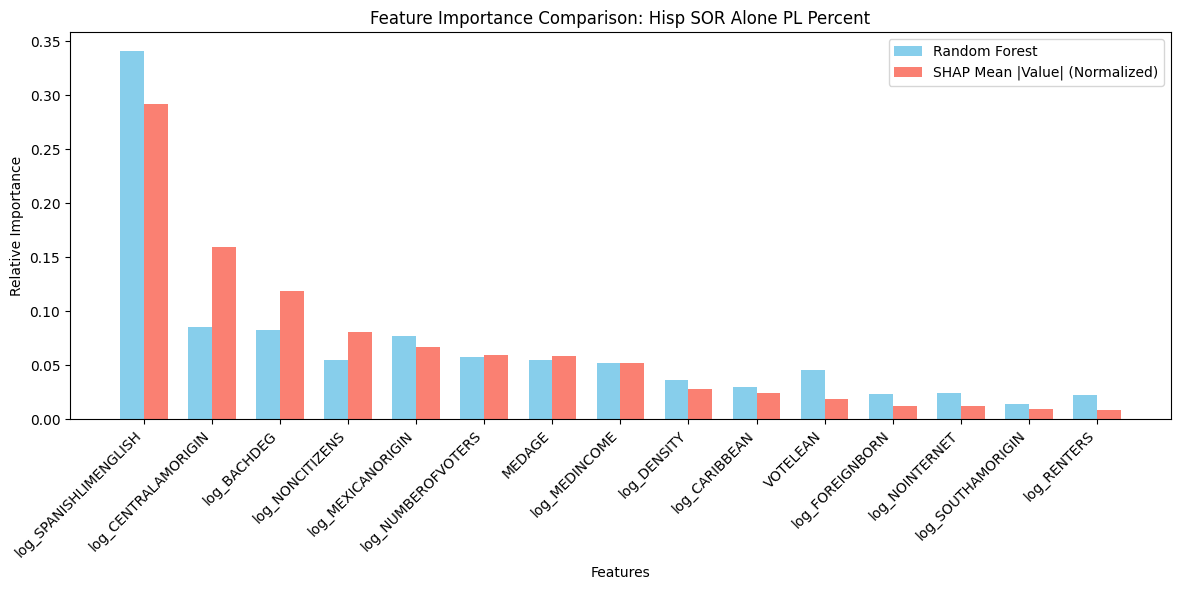

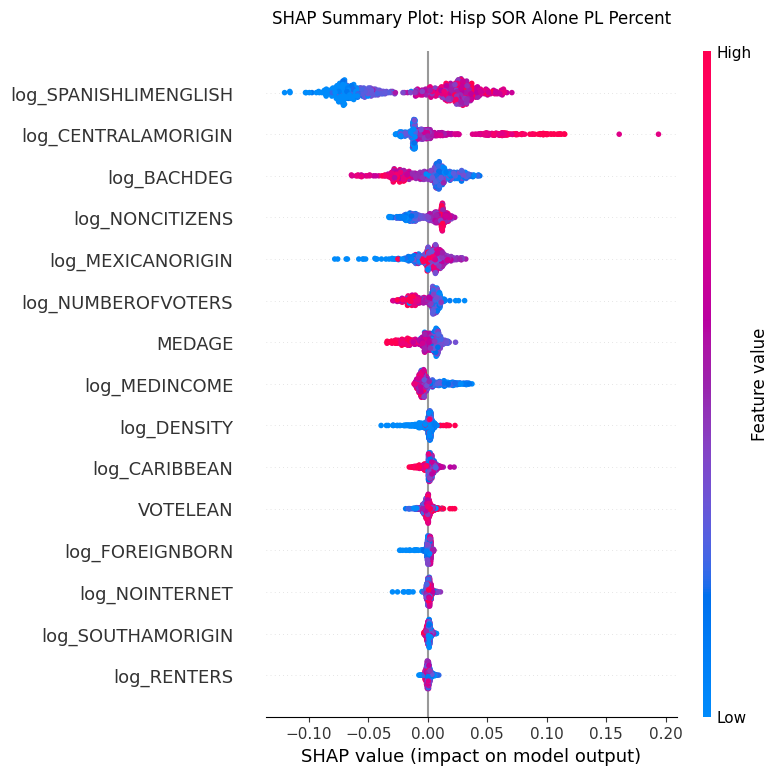

Training Random Forest Regressor for target: Hisp White SOR PL Percent...
[Hisp White SOR PL Percent] R² Score: 0.3993 | RMSE: 0.0611


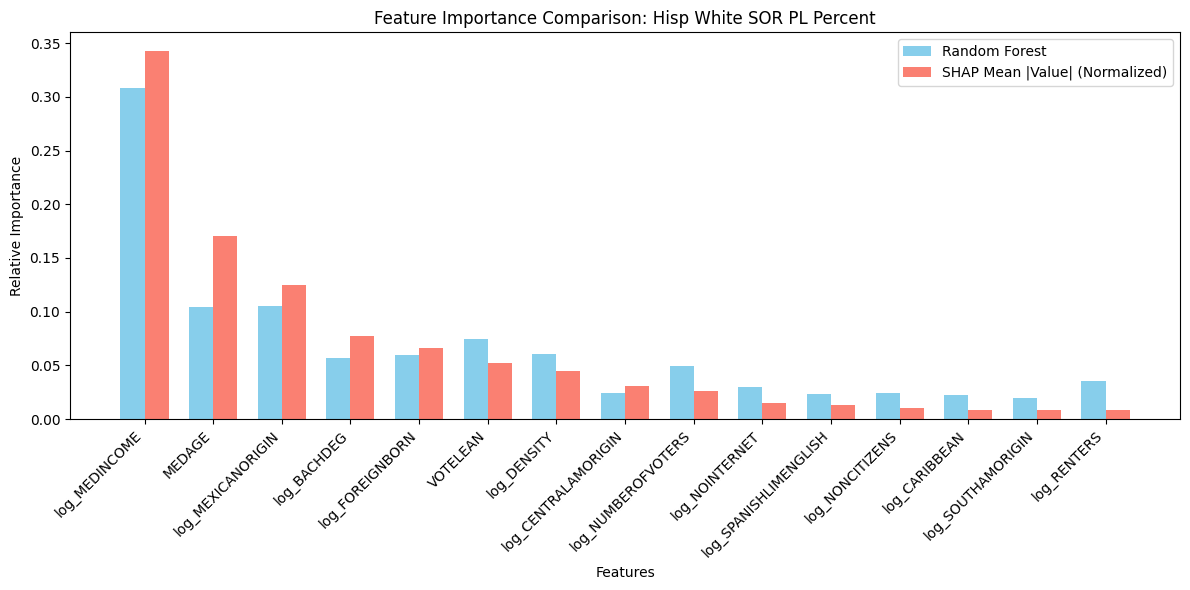

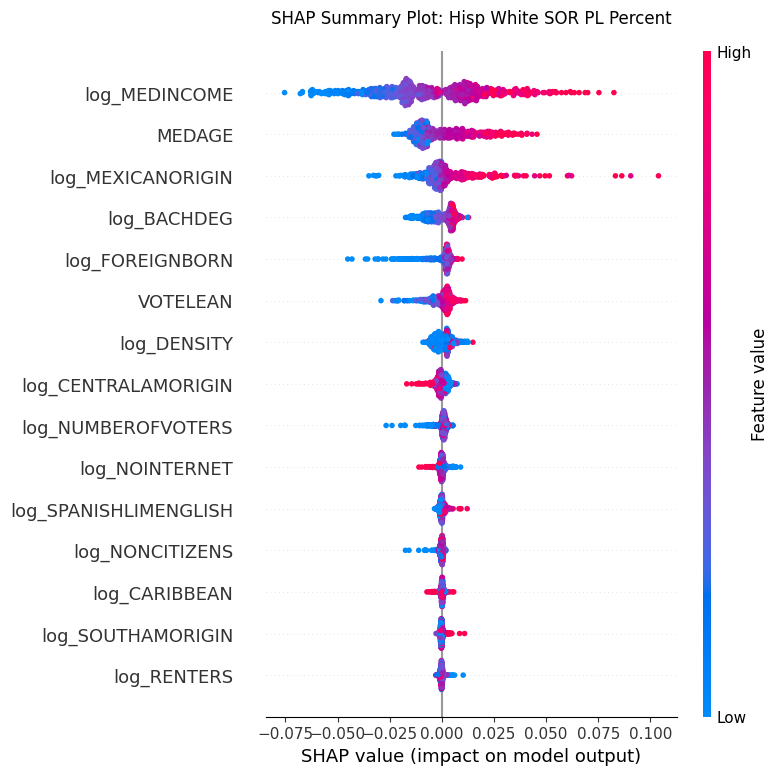

Training Random Forest Regressor for target: Hisp White Alone PL Percent...
[Hisp White Alone PL Percent] R² Score: 0.3558 | RMSE: 0.0824


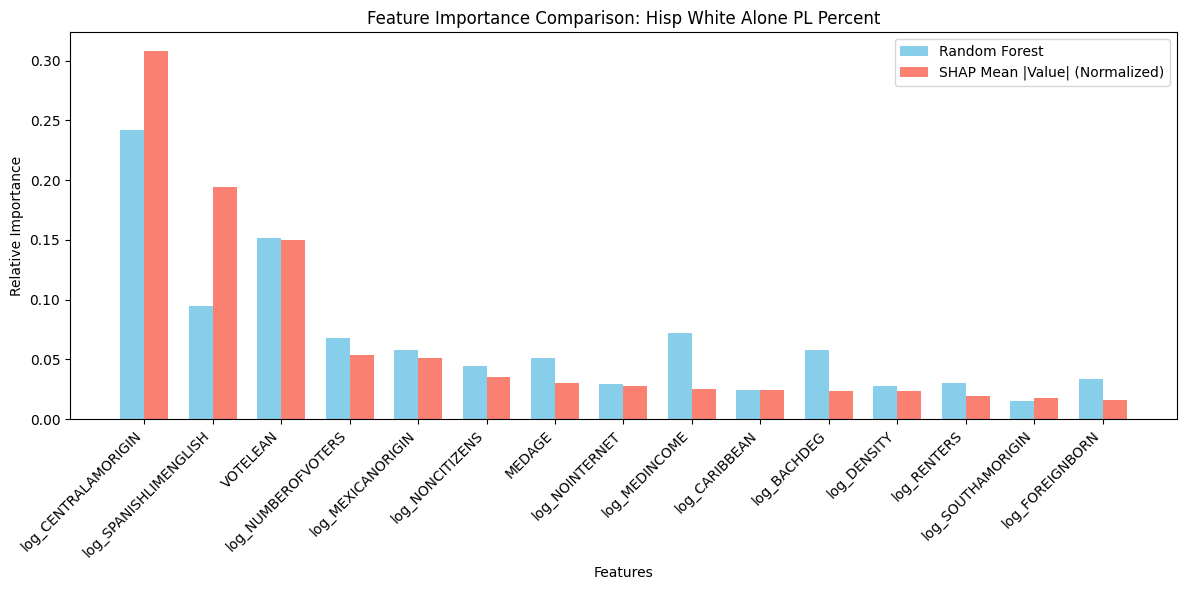

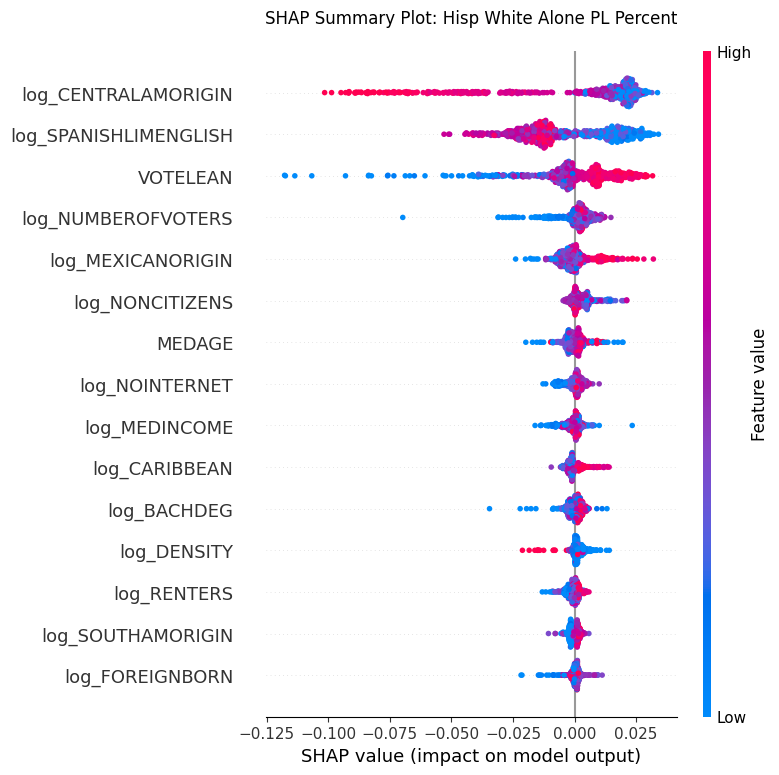

Training Random Forest Regressor for target: Hisp White PL Percent...
[Hisp White PL Percent] R² Score: 0.3990 | RMSE: 0.1064


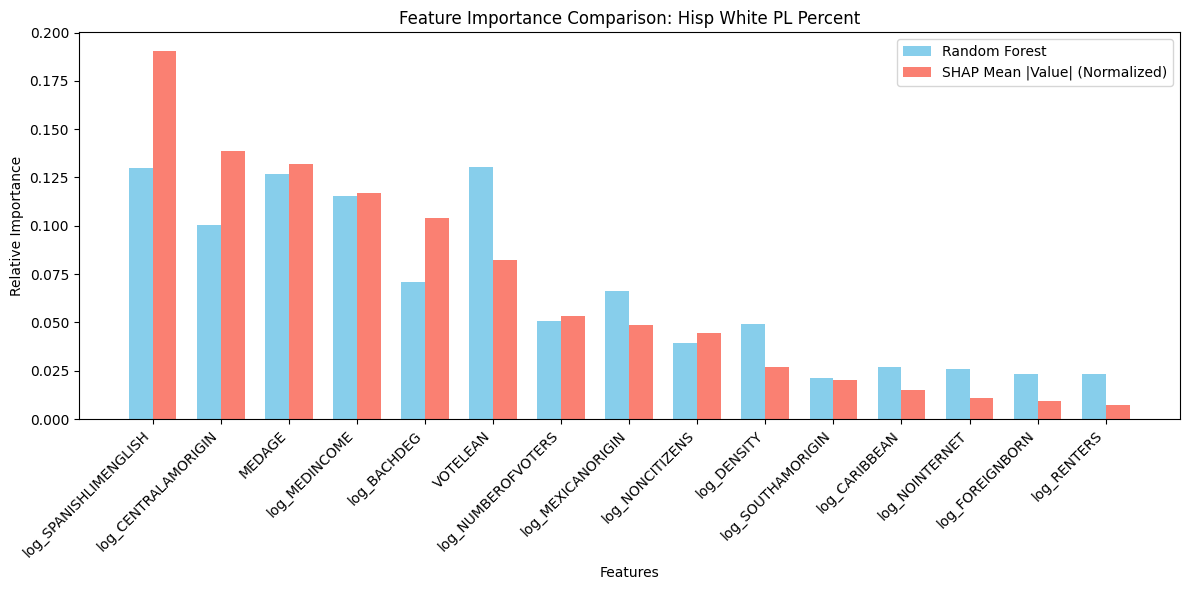

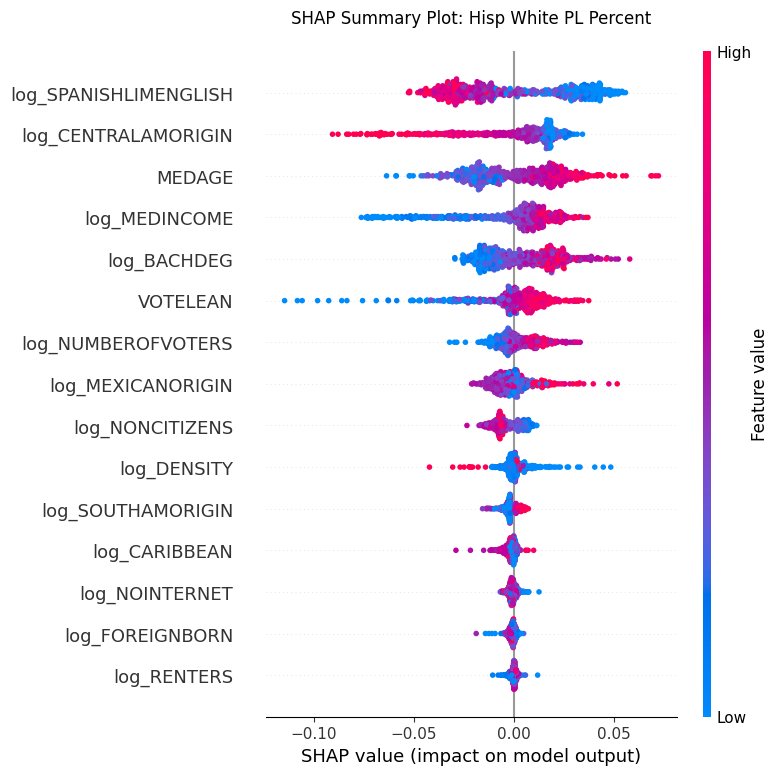


--- Top Features for Predicting SORA Proportions ---
                  Feature  RF_Importance  SHAP_Importance  SHAP_Normalized
0   log_SPANISHLIMENGLISH       0.341125         0.041616         0.291961
1     log_CENTRALAMORIGIN       0.085739         0.022783         0.159835
2             log_BACHDEG       0.082629         0.016849         0.118204
3         log_NONCITIZENS       0.054271         0.011449         0.080320
4       log_MEXICANORIGIN       0.076851         0.009576         0.067185
5      log_NUMBEROFVOTERS       0.057971         0.008454         0.059313
6                  MEDAGE       0.054321         0.008350         0.058578
7           log_MEDINCOME       0.051684         0.007406         0.051955
8             log_DENSITY       0.036506         0.003981         0.027932
9           log_CARIBBEAN       0.029893         0.003455         0.024243
10               VOTELEAN       0.045204         0.002665         0.018695
11        log_FOREIGNBORN       0.023679      

In [12]:
# --- Random-forest regression + SHAP for each continuous proportion target ---
# For every target we: split 80/20, fit a depth-limited RandomForestRegressor,
# report R2/RMSE, then compute both built-in importances and mean |SHAP| values,
# and plot a side-by-side importance bar chart plus the SHAP summary plot.
target_proportions = ['Hisp SOR Alone PL Percent', 'Hisp White SOR PL Percent',
                      'Hisp White Alone PL Percent', 'Hisp White PL Percent']

# Build the feature matrix (log1p on count covariates; see vars_log / vars_no_log)
X_features = census_and_geodata[vars_no_log].copy()
for col in vars_log:
    X_features[f'log_{col}'] = np.log1p(census_and_geodata[col])

# Store each target's importance comparison for later inspection
rf_target_importances = {}

for target in target_proportions:
    print(f"Training Random Forest Regressor for target: {target}...")

    # Align features with the target and drop incomplete rows
    model_data = pd.concat([X_features, census_and_geodata[target]], axis=1).dropna()
    X_t = model_data.drop(columns=[target])
    y_t = model_data[target]

    X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

    # Depth limited to reduce overfitting (raising max_depth could be explored)
    rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
    rf_regressor.fit(X_train, y_train)

    # Evaluate on the held-out test set
    y_pred = rf_regressor.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"[{target}] R² Score: {r2:.4f} | RMSE: {rmse:.4f}")

    # Built-in (magnitude-only) random-forest importances
    rf_importance = rf_regressor.feature_importances_

    # SHAP values -> global importance as mean absolute SHAP per feature
    explainer = shap.TreeExplainer(rf_regressor)
    shap_values = explainer.shap_values(X_test)
    global_shap_importance = np.abs(shap_values).mean(axis=0)

    # Combine both importance measures into one table
    comparison_df = pd.DataFrame({
        'Feature': X_train.columns,
        'RF_Importance': rf_importance,
        'SHAP_Importance': global_shap_importance
    })
    # Normalize SHAP to sum to 1 for comparison (RF importances already sum to 1)
    comparison_df['SHAP_Normalized'] = comparison_df['SHAP_Importance'] / comparison_df['SHAP_Importance'].sum()
    comparison_df = comparison_df.sort_values(by='SHAP_Importance', ascending=False).reset_index(drop=True)
    rf_target_importances[target] = comparison_df

    # --- Side-by-side bar chart: RF importance vs normalized SHAP ---
    top_n = comparison_df
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(top_n['Feature']))
    width = 0.35
    ax.bar(x - width / 2, top_n['RF_Importance'], width, label='Random Forest', color='skyblue')
    ax.bar(x + width / 2, top_n['SHAP_Normalized'], width, label='SHAP Mean |Value| (Normalized)', color='salmon')
    ax.set_xlabel('Features')
    ax.set_ylabel('Relative Importance')
    ax.set_title(f"Feature Importance Comparison: {target}")
    ax.set_xticks(x)
    ax.set_xticklabels(top_n['Feature'], rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Classic SHAP summary (beeswarm) plot ---
    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f"SHAP Summary Plot: {target}", pad=20)
    plt.show()

# Print the stored importance tables for each target
print("\n--- Top Features for Predicting SORA Proportions ---")
print(rf_target_importances['Hisp SOR Alone PL Percent'])

print("\n--- Top Features for Predicting 'White + Some Other Race' Proportions ---")
print(rf_target_importances['Hisp White SOR PL Percent'])

print("\n--- Top Features for Predicting White A Proportions ---")
print(rf_target_importances['Hisp White Alone PL Percent'])

print("\n--- Top Features for Predicting White Alone or in Combination Proportions ---")
print(rf_target_importances['Hisp White PL Percent'])

<Figure size 1000x600 with 0 Axes>

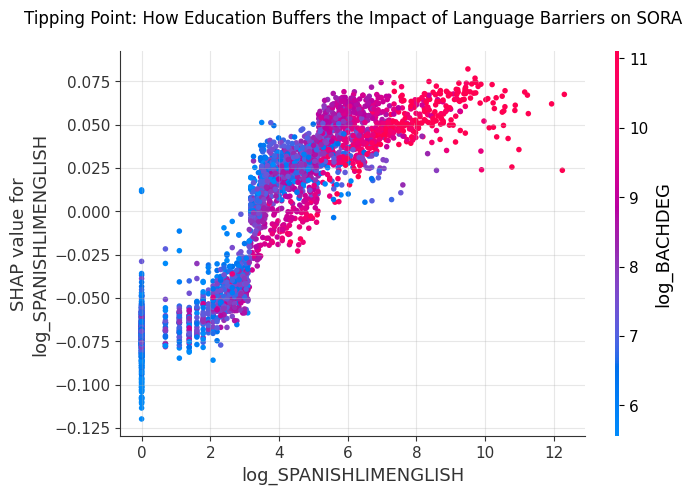

In [20]:
# --- SHAP interaction plot: how education moderates the language effect ---
# Refit a regressor on the full SORA-proportion data (no split; this is an
# explanatory plot, not an evaluation) and inspect the interaction between
# limited-English share and bachelor's-degree share.
# This is just an example of how we could use this data to make interpret-
# ations about the data. 
model_data = pd.concat([X_features, census_and_geodata['Hisp SOR Alone PL Percent']], axis=1).dropna()
X_t = model_data.drop(columns=['Hisp SOR Alone PL Percent'])
y_t = model_data['Hisp SOR Alone PL Percent']

rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42).fit(X_t, y_t)
explainer = shap.TreeExplainer(rf_regressor)
shap_values = explainer(X_t)  # full Explanation object

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "log_SPANISHLIMENGLISH",
    shap_values.values,
    X_t,
    interaction_index="log_BACHDEG",
    show=False
)
plt.title("Tipping Point: How Education Buffers the Impact of Language Barriers on SORA", pad=20)
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

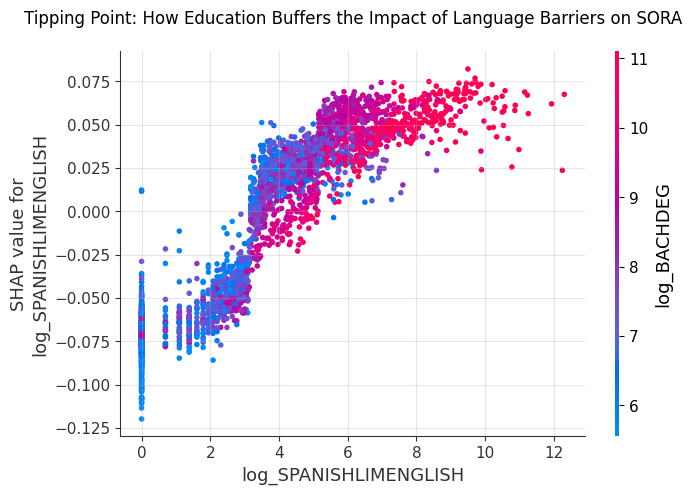

In [14]:
# The purpose of this is to look at potential correlation
model_data = pd.concat([X_features, census_and_geodata['Hisp SOR Alone PL Percent']], axis=1).dropna()
X_t = model_data.drop(columns=['Hisp SOR Alone PL Percent'])
y_t = model_data['Hisp SOR Alone PL Percent']

rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42).fit(X_t, y_t)
explainer = shap.TreeExplainer(rf_regressor)
shap_values = explainer(X_t) # Get the full Explanation object

# Creative Interaction Plot: Language vs. Education
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "log_SPANISHLIMENGLISH", 
    shap_values.values, 
    X_t, 
    interaction_index="log_BACHDEG",
    show=False
)
plt.title("Tipping Point: How Education Buffers the Impact of Language Barriers on SORA", pad=20)
plt.grid(True, alpha=0.3)
plt.show()

# Binary predictor-- not strong

In [16]:
# =============================================================================
# 6.C ALTERNATIVE REGRESSORS (lower-performing, kept for completeness)
# =============================================================================
# Polynomial (interaction-only) Lasso regression on each proportion target.
# Degree-2 interaction terms are generated, scaled, then L1-penalized so Lasso
# can zero out the weak ones; surviving coefficients are reported with direction.

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

target_proportions = ['Hisp SOR Alone PL Percent', 'Hisp White SOR PL Percent',
                      'Hisp White Alone PL Percent', 'Hisp White PL Percent']

# Build the feature matrix (log1p on count covariates)
X_features = census_and_geodata[vars_no_log].copy()
for col in vars_log:
    X_features[f'log_{col}'] = np.log1p(census_and_geodata[col])

# Store the surviving (non-zero) coefficients per target
lasso_target_coefficients = {}

for target in target_proportions:
    print(f"\nTraining Lasso Regression for target: {target}...")

    model_data = pd.concat([X_features, census_and_geodata[target]], axis=1).dropna()
    X_t = model_data.drop(columns=[target])
    y_t = model_data[target]

    X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

    # Pipeline: interaction features -> scaling (required for fair L1 penalty) -> Lasso
    model_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=0.01, max_iter=10000, random_state=42))
    ])
    model_pipeline.fit(X_train, y_train)

    # Evaluate on the test set
    y_pred = model_pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"[{target}] R² Score: {r2:.4f} | RMSE: {rmse:.4f}")

    # Map coefficients back to the generated polynomial feature names
    coefficients = model_pipeline.named_steps['regressor'].coef_
    poly_feature_names = model_pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)

    coef_df = pd.DataFrame({
        'Feature': poly_feature_names,
        'Coefficient': coefficients,
        'Absolute_Importance': np.abs(coefficients)
    })
    # Keep only features Lasso did NOT zero out
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
    coef_df['Direction'] = np.where(coef_df['Coefficient'] > 0, 'Positive (+)', 'Negative (-)')
    coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)
    coef_df = coef_df.drop(columns=['Absolute_Importance'])

    lasso_target_coefficients[target] = coef_df

# Print the top surviving features per target
print("\n--- Top Correlated Features (Lasso Selected) for Predicting SORA Proportions ---")
print(lasso_target_coefficients['Hisp SOR Alone PL Percent'].head(15))

print("\n--- Top Correlated Features (Lasso Selected) for Predicting 'White + Some Other Race' Proportions ---")
print(lasso_target_coefficients['Hisp White SOR PL Percent'].head(15))

print("\n--- Top Correlated Features (Lasso Selected) for Predicting White A Proportions ---")
print(lasso_target_coefficients['Hisp White Alone PL Percent'].head(15))

print("\n--- Top Correlated Features (Lasso Selected) for Predicting White Alone or in Combination Proportions ---")
print(lasso_target_coefficients['Hisp White PL Percent'].head(15))


Training Lasso Regression for target: Hisp SOR Alone PL Percent...
[Hisp SOR Alone PL Percent] R² Score: 0.2602 | RMSE: 0.1201

Training Lasso Regression for target: Hisp White SOR PL Percent...
[Hisp White SOR PL Percent] R² Score: 0.2050 | RMSE: 0.0703

Training Lasso Regression for target: Hisp White Alone PL Percent...
[Hisp White Alone PL Percent] R² Score: 0.1705 | RMSE: 0.0935

Training Lasso Regression for target: Hisp White PL Percent...
[Hisp White PL Percent] R² Score: 0.1965 | RMSE: 0.1230

--- Top Correlated Features (Lasso Selected) for Predicting SORA Proportions ---
                          Feature  Coefficient     Direction
0           log_SPANISHLIMENGLISH     0.029833  Positive (+)
1             log_CENTRALAMORIGIN     0.013691  Positive (+)
2              MEDAGE log_BACHDEG    -0.013575  Negative (-)
3    MEDAGE log_SPANISHLIMENGLISH     0.009778  Positive (+)
4                 log_NONCITIZENS     0.008329  Positive (+)
5  VOTELEAN log_SPANISHLIMENGLISH     0.0037

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [73]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso  
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

target_proportions = ['Hisp SOR Alone PL Percent', 'Hisp White SOR PL Percent', 'Hisp White Alone PL Percent', 'Hisp White PL Percent']

# Reconstruct feature dataframe based on your lists
X_features = census_and_geodata[vars_no_log].copy()
for col in vars_log:
    X_features[f'log_{col}'] = np.log1p(census_and_geodata[col])

# Dictionary to store the coefficient DataFrames for later inspection
lasso_target_coefficients = {}

for target in target_proportions:
    print(f"\nTraining Lasso Regression for target: {target}...")
    
    model_data = pd.concat([X_features, census_and_geodata[target]], axis=1).dropna()
    
    X_t = model_data.drop(columns=[target])
    y_t = model_data[target]
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42)
    
    # Define a pipeline: Scaling is heavily required for Lasso to penalize features fairly
    model_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(alpha=0.01, max_iter=10000, random_state=42))
])
    
    # Train the pipeline
    model_pipeline.fit(X_train, y_train)
    
    # Generate predictions on the unseen test features
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate with test data
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"[{target}] R² Score: {r2:.4f} | RMSE: {rmse:.4f}")
    
    coefficients = model_pipeline.named_steps['regressor'].coef_
    
    #  Get the dynamically generated feature names from the polynomial step
    # We pass 'X_train.columns' so it knows what the original names were
    poly_feature_names = model_pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)
    
    # 3. Build the DataFrame using the updated feature names
    coef_df = pd.DataFrame({
        'Feature': poly_feature_names,  # <-- Swapped X_train.columns for poly_feature_names
        'Coefficient': coefficients,
        'Absolute_Importance': np.abs(coefficients)
    })
    
    # Filter out features that Lasso pushed to exactly zero
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
    
    # Add a clear helper column for direction
    coef_df['Direction'] = np.where(coef_df['Coefficient'] > 0, 'Positive (+)', 'Negative (-)')
    
    # Sort by absolute importance to see the strongest drivers first
    coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)
    
    # Drop the temporary absolute column for cleaner printing
    coef_df = coef_df.drop(columns=['Absolute_Importance'])
    
    lasso_target_coefficients[target] = coef_df

# Print dataframes
print("\n--- Top Correlated Features (Lasso Selected) for Predicting SORA Proportions ---")
print(lasso_target_coefficients['Hisp SOR Alone PL Percent'].head(15))

print("\n--- Top Correlated Features (Lasso Selected) for Predicting 'White + Some Other Race' Proportions ---")
print(lasso_target_coefficients['Hisp White SOR PL Percent'].head(15))

print("\n--- Top Correlated Features (Lasso Selected) for Predicting White A Proportions ---")
print(lasso_target_coefficients['Hisp White Alone PL Percent'].head(15))

print("\n--- Top Correlated Features (Lasso Selected) for Predicting White Alone or in Combination Proportions ---")
print(lasso_target_coefficients['Hisp White PL Percent'].head(15))


Training Lasso Regression for target: Hisp SOR Alone PL Percent...
[Hisp SOR Alone PL Percent] R² Score: 0.2602 | RMSE: 0.1201

Training Lasso Regression for target: Hisp White SOR PL Percent...
[Hisp White SOR PL Percent] R² Score: 0.2050 | RMSE: 0.0703

Training Lasso Regression for target: Hisp White Alone PL Percent...
[Hisp White Alone PL Percent] R² Score: 0.1705 | RMSE: 0.0935

Training Lasso Regression for target: Hisp White PL Percent...
[Hisp White PL Percent] R² Score: 0.1965 | RMSE: 0.1230

--- Top Correlated Features (Lasso Selected) for Predicting SORA Proportions ---
                          Feature  Coefficient     Direction
0           log_SPANISHLIMENGLISH     0.029833  Positive (+)
1             log_CENTRALAMORIGIN     0.013691  Positive (+)
2              MEDAGE log_BACHDEG    -0.013575  Negative (-)
3    MEDAGE log_SPANISHLIMENGLISH     0.009778  Positive (+)
4                 log_NONCITIZENS     0.008329  Positive (+)
5  VOTELEAN log_SPANISHLIMENGLISH     0.0037

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [17]:
# --- Lasso on a logit-transformed target ---
# Proportions are bounded in [0, 1], so we model them on the log-odds scale and
# invert the prediction back to a percentage. TransformedTargetRegressor applies
# the forward/inverse transforms around the scaled Lasso pipeline.
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Lasso


def to_log_odds(y):
    """Map a percentage (0-100) to the log-odds scale, clipped away from 0/1."""
    y_scaled = np.clip(y / 100.0, 0.0001, 0.9999)
    return np.log(y_scaled / (1 - y_scaled))


def from_log_odds(y_prime):
    """Invert :func:`to_log_odds`, returning a percentage (0-100)."""
    return (1 / (1 + np.exp(-y_prime))) * 100


for target in target_proportions:
    model_data = pd.concat([X_features, census_and_geodata[target]], axis=1).dropna()
    X_t = model_data.drop(columns=[target])
    y_t = model_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

    # Scaled Lasso, wrapped so the target is fit on the log-odds scale
    lasso_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=0.01, random_state=42))
    ])
    transformed_model = TransformedTargetRegressor(
        regressor=lasso_pipeline,
        func=to_log_odds,
        inverse_func=from_log_odds
    )
    transformed_model.fit(X_train, y_train)

    # Evaluate on the original 0-100% scale
    y_pred = transformed_model.predict(X_test)
    print(f"Transformed Lasso R² Score: {r2_score(y_test, y_pred):.4f}")

    # Directional (signed) coefficients from the inner Lasso
    coefficients = transformed_model.regressor_.named_steps['regressor'].coef_
    coef_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': coefficients,
        'Absolute_Importance': np.abs(coefficients)
    })
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
    coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)
    coef_df = coef_df.drop(columns=['Absolute_Importance'])

    print("\n--- Top Correlated Features (Logit-Transformed Lasso) ---")
    print(coef_df.head(20))

Transformed Lasso R² Score: 0.1606

--- Top Correlated Features (Logit-Transformed Lasso) ---
                  Feature  Coefficient
0         log_NONCITIZENS     0.128843
1             log_BACHDEG    -0.125666
2   log_SPANISHLIMENGLISH     0.112395
3       log_MEXICANORIGIN     0.099616
4          log_NOINTERNET     0.079702
5       log_SOUTHAMORIGIN    -0.076839
6     log_CENTRALAMORIGIN     0.067544
7                VOTELEAN     0.043202
8                  MEDAGE    -0.033745
9           log_CARIBBEAN    -0.004057
10          log_MEDINCOME    -0.003811
Transformed Lasso R² Score: 0.2021

--- Top Correlated Features (Logit-Transformed Lasso) ---
               Feature  Coefficient
0        log_MEDINCOME     0.120874
1    log_MEXICANORIGIN     0.091851
2             VOTELEAN     0.075648
3      log_FOREIGNBORN     0.075491
4               MEDAGE     0.066421
5   log_NUMBEROFVOTERS     0.064436
6  log_CENTRALAMORIGIN    -0.052067
7          log_DENSITY    -0.019497
Transformed Lasso R²

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(


In [18]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Lasso

def to_log_odds(y):
    y_scaled = np.clip(y / 100.0, 0.0001, 0.9999)
    return np.log(y_scaled / (1 - y_scaled))

def from_log_odds(y_prime):
    return (1 / (1 + np.exp(-y_prime))) * 100


for target in target_proportions:

    model_data = pd.concat([X_features, census_and_geodata[target]], axis=1).dropna()
    
    X_t = model_data.drop(columns=[target])
    y_t = model_data[target]
    X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42)
    # Wrap your Lasso pipeline inside the target transformer
    lasso_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=0.01, random_state=42))
    ])

    transformed_model = TransformedTargetRegressor(
        regressor=lasso_pipeline,
        func=to_log_odds,
        inverse_func=from_log_odds
    )

    # Train the model
    transformed_model.fit(X_train, y_train)

    # Evaluate predictions on the original 0-100% scale
    y_pred = transformed_model.predict(X_test)
    print(f"Transformed Lasso R² Score: {r2_score(y_test, y_pred):.4f}")

    # To get your directional coefficients:
    coefficients = transformed_model.regressor_.named_steps['regressor'].coef_
    coef_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': coefficients,
        'Absolute_Importance': np.abs(coefficients)
    })
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()



    coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)

   
    coef_df = coef_df.drop(columns=['Absolute_Importance'])

    
    print("\n--- Top Correlated Features (Logit-Transformed Lasso) ---")
    print(coef_df.head(20))

Transformed Lasso R² Score: 0.1606

--- Top Correlated Features (Logit-Transformed Lasso) ---
                  Feature  Coefficient
0         log_NONCITIZENS     0.128843
1             log_BACHDEG    -0.125666
2   log_SPANISHLIMENGLISH     0.112395
3       log_MEXICANORIGIN     0.099616
4          log_NOINTERNET     0.079702
5       log_SOUTHAMORIGIN    -0.076839
6     log_CENTRALAMORIGIN     0.067544
7                VOTELEAN     0.043202
8                  MEDAGE    -0.033745
9           log_CARIBBEAN    -0.004057
10          log_MEDINCOME    -0.003811
Transformed Lasso R² Score: 0.2021

--- Top Correlated Features (Logit-Transformed Lasso) ---
               Feature  Coefficient
0        log_MEDINCOME     0.120874
1    log_MEXICANORIGIN     0.091851
2             VOTELEAN     0.075648
3      log_FOREIGNBORN     0.075491
4               MEDAGE     0.066421
5   log_NUMBEROFVOTERS     0.064436
6  log_CENTRALAMORIGIN    -0.052067
7          log_DENSITY    -0.019497
Transformed Lasso R²

/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(
/Users/ireland/Desktop/Spring2026/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:196: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(


In [19]:
# =============================================================================
# 6.D LOG-RATIO REGRESSION
# =============================================================================
# Instead of modeling each proportion separately, model log-ratios of each race
# choice against "any White identification". Higher values mean stronger
# identification with the numerator category relative to White. A small epsilon
# avoids log(0) / division by zero. Each target is fit with both RidgeCV (L2)
# and LassoCV (L1), each cross-validating over a grid of penalty strengths.
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Epsilon guards against exact-zero proportions in the ratios below
epsilon = 1e-5
p_sora = census_and_geodata['Hisp SOR Alone PL Percent'] + epsilon
p_w_sor = census_and_geodata['Hisp White SOR PL Percent'] + epsilon
p_whitea = census_and_geodata['Hisp White Alone PL Percent'] + epsilon
p_white_total = census_and_geodata['Hisp White PL Percent'] + epsilon  # baseline anchor

# Log-ratios against "any White identification" (the broad White umbrella)
census_and_geodata['y_1_SORA_vs_WhiteTotal'] = np.log(p_sora / p_white_total)       # SOR-only vs any White
census_and_geodata['y_2_WhiteSOR_vs_WhiteTotal'] = np.log(p_w_sor / p_white_total)  # White+SOR vs any White
census_and_geodata['y_3_WhiteA_vs_WhiteTotal'] = np.log(p_whitea / p_white_total)   # White-alone vs any White

log_ratio_targets = ['y_1_SORA_vs_WhiteTotal', 'y_2_WhiteSOR_vs_WhiteTotal', 'y_3_WhiteA_vs_WhiteTotal']

# -----------------------------------------------------------------------------
# RIDGE REGRESSION (L2)
# -----------------------------------------------------------------------------
for target_name in log_ratio_targets:
    print(f"\n==================================================")
    print(f"RUNNING REGULARIZED LINEAR REGRESSION FOR: {target_name}")
    print(f"==================================================")

    model_data = pd.concat([X_features, census_and_geodata[target_name]], axis=1).dropna()
    X_lr = model_data.drop(columns=[target_name])
    y_lr = model_data[target_name]

    X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

    # Standardize, then RidgeCV over 100 penalty strengths (1e-3 .. 1e3)
    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge_cv', RidgeCV(alphas=np.logspace(-3, 3, 100)))
    ])
    ridge_pipeline.fit(X_train, y_train)

    best_ridge_alpha = ridge_pipeline.named_steps['ridge_cv'].alpha_
    print(f"Best Ridge Alpha: {best_ridge_alpha:.4f}")

    y_pred = ridge_pipeline.predict(X_test)
    print(f"Test R² Score:    {r2_score(y_test, y_pred):.4f}")
    print(f"Test RMSE:        {mean_squared_error(y_test, y_pred):.4f}\n")

    coefficients = ridge_pipeline.named_steps['ridge_cv'].coef_
    coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefficients})
    coef_df['Abs_Magnitude'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Abs_Magnitude', ascending=False).drop(columns=['Abs_Magnitude'])
    print(coef_df.reset_index(drop=True))

# -----------------------------------------------------------------------------
# LASSO REGRESSION (L1)
# -----------------------------------------------------------------------------
for target_name in log_ratio_targets:
    print(f"\n==================================================")
    print(f"RUNNING LASSO REGRESSION FOR: {target_name}")
    print(f"==================================================")

    model_data = pd.concat([X_features, census_and_geodata[target_name]], axis=1).dropna()
    X_lr = model_data.drop(columns=[target_name])
    y_lr = model_data[target_name]

    X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

    # Standardize, then LassoCV over 100 penalty strengths with 5-fold CV
    lasso_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso_cv', LassoCV(alphas=np.logspace(-5, 1, 100), cv=5, random_state=42, max_iter=10000))
    ])
    lasso_pipeline.fit(X_train, y_train)

    best_alpha = lasso_pipeline.named_steps['lasso_cv'].alpha_
    print(f"Best Lasso Alpha: {best_alpha}")

    y_pred = lasso_pipeline.predict(X_test)
    print(f"Test R² Score:    {r2_score(y_test, y_pred):.4f}")
    print(f"Test RMSE:        {mean_squared_error(y_test, y_pred):.4f}\n")

    coefficients = lasso_pipeline.named_steps['lasso_cv'].coef_
    coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefficients})
    # Drop zeroed-out coefficients; copy to avoid SettingWithCopyWarning
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
    coef_df['Abs_Magnitude'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Abs_Magnitude', ascending=False).drop(columns=['Abs_Magnitude'])
    print(coef_df.reset_index(drop=True))


RUNNING REGULARIZED LINEAR REGRESSION FOR: y_1_SORA_vs_WhiteTotal
Best Ridge Alpha: 30.5386
Test R² Score:    0.0491
Test RMSE:        1.3851

                  Feature  Coefficient
0          log_NOINTERNET     0.713133
1             log_BACHDEG    -0.392350
2             log_RENTERS    -0.371059
3         log_NONCITIZENS     0.336217
4       log_MEXICANORIGIN     0.231755
5       log_SOUTHAMORIGIN    -0.177416
6                  MEDAGE    -0.137581
7     log_CENTRALAMORIGIN     0.122380
8         log_FOREIGNBORN    -0.075790
9   log_SPANISHLIMENGLISH     0.074962
10          log_MEDINCOME     0.067644
11          log_CARIBBEAN    -0.060770
12               VOTELEAN    -0.028709
13            log_DENSITY     0.009870
14     log_NUMBEROFVOTERS    -0.004649

RUNNING REGULARIZED LINEAR REGRESSION FOR: y_2_WhiteSOR_vs_WhiteTotal
Best Ridge Alpha: 46.4159
Test R² Score:    0.1988
Test RMSE:        0.4861

                  Feature  Coefficient
0             log_RENTERS    -0.355437
1     

# Interpretation of Results — National Predictive-Modeling Notebook

Organized by section so each block can be pasted as a markdown cell beneath the matching code. All model metrics use the same 80/20 split (`random_state=42`).

## 6.A Dominant-race classification (three binary targets)

Each target was modeled three ways: a naive baseline (constant majority-class), an L1 logistic regression, and a random forest. Comparing test accuracy against the baseline tells you how much signal the covariates actually add.

| Target | Baseline test acc | Logistic test acc | RF test acc | RF test log-loss |
|---|---|---|---|---|
| **Most_SOR** | 0.596 | 0.720 | **0.755** | 0.509 |
| **Most_White_SOR** | 0.897 | 0.890 | **0.913** | 0.267 |
| **Most_White** | 0.700 | 0.746 | **0.776** | 0.445 |

Three things stand out:

**SOR is the most "learnable" target.** Its baseline is near a coin flip (0.60), and the models lift accuracy by ~16 points to 0.755 — the largest gain of the three. The covariates genuinely explain who picks Some Other Race.

**White+SOR's high accuracy is misleading.** The baseline is already 0.897 because the class is rare (most counties are *not* White+SOR-dominant), so always guessing "no" is right 90% of the time. The logistic model actually does *slightly worse* than the baseline (0.890), and the RF adds only ~1.6 points. This is the same "weakly determined middle category" pattern from the descriptive notebook, now confirmed under prediction: there's very little learnable signal here beyond the base rate.

**The random forest overfits modestly but wins everywhere.** Across all three targets, RF train accuracy (0.88–0.92) sits well above test accuracy (0.755–0.913), the classic gap. It still beats the logistic model on every target, so the relationships have meaningful nonlinearity, but the `max_depth=8` cap is doing real work and could be tuned further.

**What drives each choice (logistic coefficients + RF importance, in agreement):**

- **Most_SOR:** limited-English (logistic coef +0.85, top RF importance 0.16) and non-citizens (+0.78) push toward SOR; education (−0.62), number of voters (−0.67), and foreign-born (−0.46) push away. Median income was zeroed out entirely by the L1 penalty — it carries no independent signal once the others are present.
- **Most_White_SOR:** dominated by education (+1.71) and renters (−1.45), with median income the top RF feature (0.157). Both non-citizens and number-of-voters were zeroed out. The story here is more socioeconomic (income/education/housing) than immigration-origin.
- **Most_White:** density is the overwhelming driver (logistic coef −4.37 — by far the largest magnitude in the section), so White-alone dominance collapses as counties get denser. VOTELEAN flips positive here (+0.18) consistent with the descriptive finding that White-alone tracks Republican-leaning areas.

## 6.B Continuous proportions — random forest + SHAP

Modeling the actual share (not just the dominant class) with RF regression:

| Target | R² | RMSE |
|---|---|---|
| **SORA proportion** | **0.432** | 0.105 |
| White+SOR proportion | 0.399 | 0.061 |
| White-alone-or-combo | 0.399 | 0.106 |
| White-alone proportion | 0.356 | 0.082 |

SORA is again the best-predicted target (R² 0.43), and White-alone the worst (0.36), echoing the classification results. None of these R² values is high in absolute terms — a reminder that county-level demographics explain a meaningful *minority* of the variation in race identification, leaving most of it to local history, enumeration practice, and unobserved factors.

**SHAP confirms and signs the importances.** The RF and SHAP rankings agree closely (the bar charts line up), but SHAP adds direction:

- **SORA** is driven overwhelmingly by **limited-English** (29% of normalized SHAP, more than double the next feature) and **Central American origin** (16%). The beeswarm shows the expected direction cleanly: high limited-English (red points) sit on the positive SHAP side, low (blue) on the negative.
- **White+SOR** is led by **median income** (34% of SHAP — much higher-income counties drive this category) and median age (17%). This is the only target where income is the dominant feature, reinforcing that White+SOR is the socioeconomically-defined choice rather than the immigration-defined one.
- **White-alone** leans on **Central American origin** (31%, negatively — more Central American origin means *less* White-alone) and limited-English, with VOTELEAN third (15%).

## SHAP interaction: education buffers language (the "tipping point" plot)

This is the most interesting single finding in the notebook. The dependence plot puts limited-English on the x-axis, its SHAP contribution to SORA on the y-axis, and colors points by education (`log_BACHDEG`).

The relationship is clearly **nonlinear with a threshold around x ≈ 3**: below it, limited-English *suppresses* the SORA prediction (negative SHAP); above it, the effect turns sharply positive and keeps climbing. That S-shape is exactly why the random forest beats the linear models on this target — a straight line can't capture it.

The color adds the interaction story: at any given level of limited-English past the threshold, **higher-education counties (red) sit above lower-education counties (blue)** — education *amplifies* rather than buffers the positive language effect on the upper branch, while on the low branch the points are mostly blue. The plot's title frames this as education "buffering" language barriers; the data more precisely show education and language interacting, with their joint high-end pushing strongly toward SORA. Worth a second look when you write this up, since the title and the visual point in slightly different directions.

## 6.C / 6.D Alternative regressors (the methods that worked less well)

These are honestly labeled in the notebook as lower-performing, and the numbers bear that out:

- **Polynomial (interaction) Lasso:** R² of 0.260 (SORA), 0.205 (White+SOR), 0.171 (White-alone), 0.197 (White-combo) — well below the random forest's 0.36–0.43. Lasso keeps very few terms (only 3 survive for White+SOR), and the survivors are mostly interaction terms like `MEDAGE × log_SPANISHLIMENGLISH`, which are hard to interpret and don't recover the RF's performance.
- **Logit-transformed Lasso:** essentially the same R² (0.16–0.24). Modeling on the log-odds scale is theoretically cleaner for bounded proportions but didn't help here, which suggests the bounding wasn't the main source of error — nonlinearity was.
- **Log-ratio Ridge/Lasso:** the weakest of all. The SORA-vs-White ratio gets R² ≈ 0.05 and the White-alone-vs-White ratio R² ≈ 0.015, with large RMSE (1.39 for the SORA ratio). The log-ratio transform spreads the target so widely that the linear models capture almost nothing.

**The consistent message across 6.C–6.D:** linear models — even with interactions, target transforms, and heavy regularization — top out around R² 0.26, while the random forest reaches 0.43. The gap is the value of the nonlinear threshold effects that the SHAP interaction plot made visible. These sections are worth keeping precisely *because* they establish that the nonlinearity is essential, not incidental.

## Overall takeaways

1. **SORA is the predictable pole, White+SOR the unpredictable middle, White-alone in between** — the same hierarchy appears in classification accuracy, regression R², and the descriptive notebook's correlations. Three independent angles agreeing is a strong result.
2. **Limited-English + Central American origin drive SORA; income drives White+SOR; density/partisanship drive White-alone.** Each category has a distinct signature except White+SOR, which is the faintest.
3. **Nonlinearity matters.** The RF's ~10–17 point edge over linear models, and the threshold shape in the SHAP interaction plot, mean the relationships are not well captured by linear or even polynomial specifications.
4. **Ceiling on explanation.** Best-case R² ≈ 0.43 means county demographics explain under half the variance in Hispanic race identification — a substantive but partial story, which is itself worth stating plainly in any writeup.